In [2]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Load in genoprobs data

In [55]:
genoprobs_path = '/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/genoprobs_rescaled.csv'
genoprobs = pd.read_csv(genoprobs_path)
genoprobs = genoprobs.rename(columns={'0': 'MouseID'})

In [5]:
# confirm standardization
np.mean(genoprobs.iloc[:, 1:].values), np.std(genoprobs.iloc[:, 1:].values)

(-3.09815293583609e-19, 1.0)

Text(0.5, 1.0, 'Distribution of genoprobs')

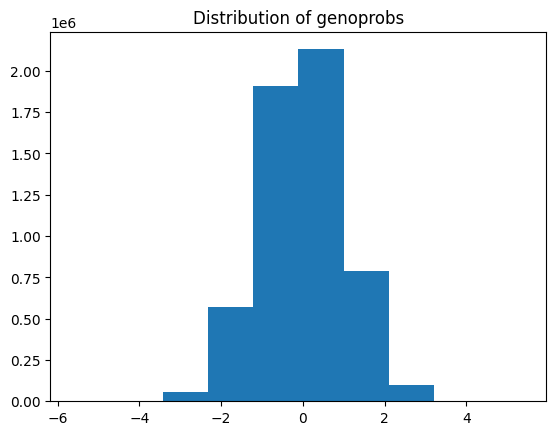

In [9]:
plt.hist(genoprobs.iloc[:, 1:].values.flatten())
plt.title('Distribution of genoprobs')

Load in physiological data

In [3]:
physio_data_unstandardized = pd.read_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/nature_filtered_nonan_cfc.csv')
cfc_data = pd.read_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/cfc_data_filtered.csv')
physio_data = pd.merge(physio_data_unstandardized, cfc_data.iloc[:, -2:], left_on='MouseID', right_on='Mouse.ID')
bin_edges = [0, 25, 50, 75, 100]
bin_labels = range(4)
physio_data['cfc_bin'] = pd.cut(physio_data['CFC.24mo.Average'], bins=bin_edges, labels=bin_labels, right=True, include_lowest=True)
physio_data

,MouseID,Generation,SurvDays,Y1A_BW_BW,Y2A_BW_BW,Y3A_BW_BW,Y1_Glu.F_Glucose,Y2_Glu.F_Glucose,Y3_Glu.F_Glucose,Y1_Echo_BPM,...,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num,Diet,Mouse.ID,CFC.24mo.Average,cfc_bin
0,DO-40-2162,28,1611,24.787142,26.993230,23.645309,164.713839,134.572768,74.479328,499.174601,...,168.389945,179.558615,0.032865,0.133616,0.159587,1,40,DO-40-2162,3.78,0
1,DO-40-2179,28,1557,30.432753,23.594599,23.529931,161.043852,71.901384,69.226421,495.841743,...,181.741358,208.833723,0.183285,0.231782,0.235033,1,40,DO-40-2179,26.71,1
2,DO-40-2181,28,1533,20.747600,19.072890,20.528352,161.043852,93.048894,60.575167,520.949018,...,204.078358,158.799723,0.069442,0.231782,0.197085,1,40,DO-40-2181,27.02,1
3,DO-40-2187,28,1520,25.977819,29.254446,30.242503,127.747193,85.358891,71.148922,466.210754,...,223.139358,208.833223,0.106295,0.174654,0.216059,1,40,DO-40-2187,50.40,2
4,DO-40-2099,26,1638,24.242912,23.626717,22.912834,166.520150,72.692867,59.960123,464.789558,...,173.953709,153.357082,0.110173,0.155822,0.285573,1,40,DO-40-2099,34.18,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,DO-2D-4007,22,771,40.141463,46.980545,67.590983,112.556159,165.312618,261.476515,554.545551,...,161.382753,58.352082,0.301015,0.209083,0.555556,3,2D,DO-2D-4007,23.69,0
500,DO-1D-3030,22,748,24.315156,29.916707,67.590983,139.326564,136.439061,261.476515,544.317015,...,138.051810,58.352082,0.301015,0.082493,0.555556,4,1D,DO-1D-3030,29.78,1
501,DO-20-1021,22,738,30.809768,38.120260,67.590983,168.911742,152.502965,261.476515,542.558402,...,162.770810,58.352082,0.301015,0.224366,0.555556,2,20,DO-20-1021,18.22,0
502,DO-AL-0002,22,755,30.261862,48.841393,67.590983,139.018370,125.113095,261.476515,477.144237,...,117.007253,58.352082,0.301015,0.277963,0.555556,5,AL,DO-AL-0002,57.42,2


Standardize physiological data

In [4]:
grouped_cols = {}
for col in physio_data.columns[3:-5]:
    base = re.sub(r"^Y[a-zA-Z0-9]+_", "", col)
    grouped_cols.setdefault(base, []).append(col)
physio_data_stand = physio_data.copy()
for base_name, cols in grouped_cols.items():
    group_values = physio_data[cols].values
    mean = group_values.mean()
    std = group_values.std(ddof=0)

    for col in cols: 
        physio_data_stand[col] = (physio_data[col] - mean) / std

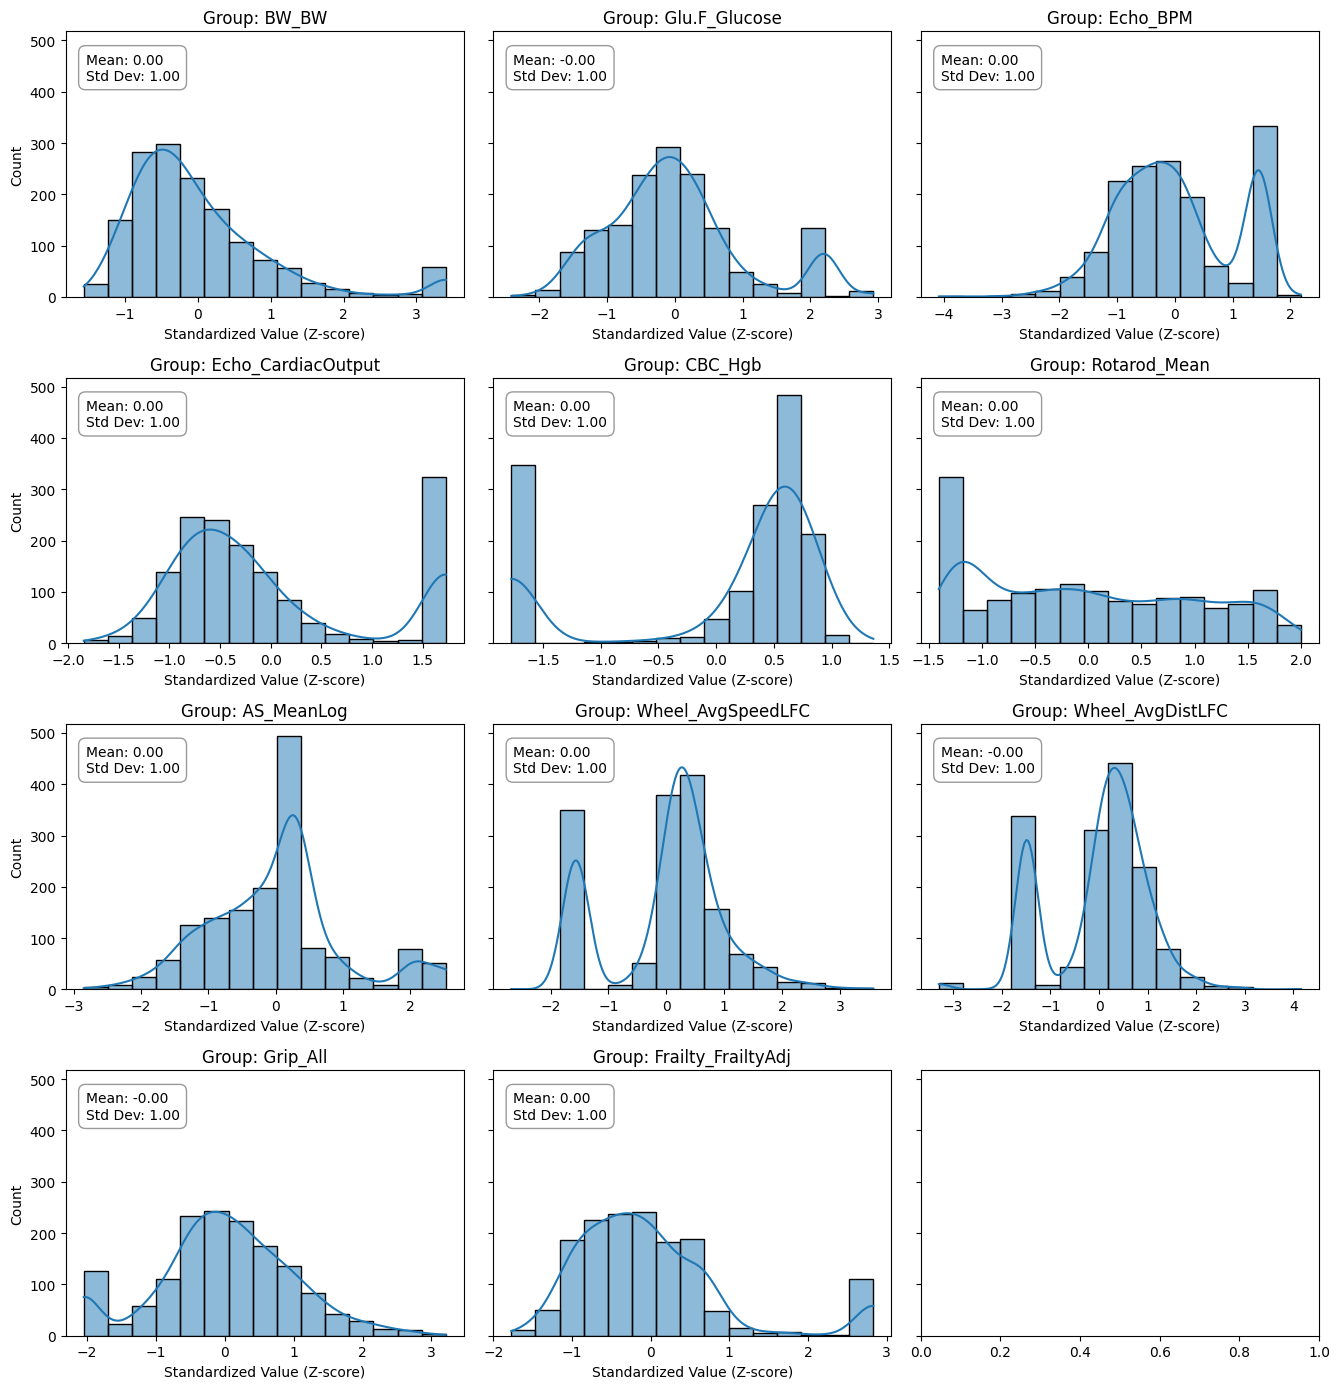

In [48]:
# Verify standardization with plotting 
fig, axes = plt.subplots(nrows=math.ceil(len(grouped_cols) / 3), ncols = 3, figsize=(4.5*3, 3.5*4), sharey=True)
axes_flat = np.array(axes).flatten()
for idx, (base_name, cols) in enumerate(grouped_cols.items()):
    ax = axes_flat[idx]
    group_all_vals = physio_data_stand[cols].values.flatten()
    sns.histplot(group_all_vals, ax=ax, kde=True, bins=15)
    ax.set_title(f'Group: {base_name}')
    ax.set_xlabel('Standardized Value (Z-score)')
    ax.set_ylabel('Count')

    combined_mean = group_all_vals.mean()
    combined_std = group_all_vals.std(ddof=0)
    text_str = f'Mean: {combined_mean:.2f}\nStd Dev: {combined_std:.2f}'
    ax.text(0.05, 0.92, text_str, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray', ), )

plt.tight_layout()
plt.show()

Combine datasets

In [56]:
joined_genetic_physio = pd.merge(genoprobs, physio_data_stand, on='MouseID', how='inner')

In [ ]:
joined_genetic_physio

,MouseID,0.1,1,2,3,4,5,6,7,8,...,Y2A_Grip_All,Y3A_Grip_All,Y1A_Frailty_FrailtyAdj,Y2A_Frailty_FrailtyAdj,Y3A_Frailty_FrailtyAdj,Diet_num,Diet,Mouse.ID,CFC.24mo.Average,cfc_bin
0,DO-1D-3001,0.885234,1.036678,1.103385,1.452176,-0.252292,1.184701,0.381302,-0.684006,1.182885,...,-0.044566,-0.397337,0.677814,-0.192370,-0.013243,4,1D,DO-1D-3001,0.84,0
1,DO-1D-3003,1.156802,-0.055468,-2.028303,-1.758717,-1.483365,0.146188,0.546376,1.862347,-0.141052,...,-0.428362,-0.871067,0.677814,-0.260886,0.078835,4,1D,DO-1D-3003,83.69,3
2,DO-1D-3010,0.147212,-0.629090,0.095689,-0.822066,-1.147267,0.014700,0.237685,-1.764237,-1.134055,...,-0.326418,-0.343365,0.677814,-0.260886,-0.402948,4,1D,DO-1D-3010,36.71,1
3,DO-1D-3011,0.501676,-1.656495,0.752401,-0.348172,1.043520,-0.411199,1.418046,-1.336511,-0.988819,...,0.021397,0.112384,0.677814,-0.421480,0.400023,4,1D,DO-1D-3011,21.96,0
4,DO-1D-3013,-1.894295,-0.589873,0.736833,0.101999,-0.042866,0.525641,-0.812557,0.540155,0.514178,...,-0.242464,-2.047151,0.677814,-0.227997,2.832238,4,1D,DO-1D-3013,6.93,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
496,DO-AL-0186,-0.408746,0.723953,-0.114496,0.852664,-0.156098,-0.293482,0.724477,-1.353684,-0.640700,...,0.089506,-2.047151,-0.800423,-0.711141,2.832238,5,AL,DO-AL-0186,20.44,0
497,DO-AL-0188,0.885158,-0.713064,0.707135,-0.531217,1.003639,1.606643,0.987814,-0.958576,-1.891393,...,0.203441,-0.258503,-1.121611,-0.068764,-0.201838,5,AL,DO-AL-0188,18.31,0
498,DO-AL-0191,0.269565,0.035678,-0.173052,-1.004266,-1.580964,0.475946,0.805426,0.353003,0.781255,...,-0.138374,-2.047151,-0.571312,0.320941,2.832238,5,AL,DO-AL-0191,24.71,0
499,DO-1D-3083,-1.650913,0.649956,-0.438226,0.676653,-0.926468,1.070770,0.104359,0.712658,1.142204,...,1.109010,0.646413,-1.606996,-0.746425,0.010679,4,1D,DO-1D-3083,31.07,1


In [59]:
joined_genetic_physio.to_csv('/home/rachel/Desktop/mm-vae data/caloric_restriction_DO_mice/do_mice_data_standardized.csv', index=False)